In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain_core.messages import RemoveMessage

In [3]:
model = ChatOllama(model="llama3.2:1b")

In [4]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [6]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [7]:
graph = builder.compile(checkpointer=InMemorySaver())

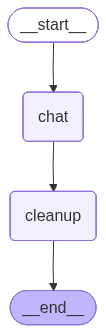

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [10]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='1e151cc7-f20f-46ee-9710-27a97a5393d6'),
  AIMessage(content="Langchain is a decentralized, open-source, AI-powered chat application that enables developers to build and deploy conversational interfaces on any platform or device. It's built using the Graphene framework and provides a robust set of features for building and managing complex conversations.\n\n**Key features:**\n\n1. **Graph database**: Langchain uses a graph database to store conversation data, allowing for efficient storage and retrieval of context-dependent information.\n2. **Natural Language Processing (NLP)**: The platform incorporates advanced NLP capabilities, including intent recognition, entity extraction, and dialogue management.\n3. **Conversational AI**: Langchain provides a set of pre-built conversational AI models that can be used to build custom chatbots or integrate with existing platforms.\n4. **Decentra

In [11]:
# total 14 message are in the state as it smore than 10 last 6 will be removed and remaining messages will be 8
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
